# What do families ask for?

**Business question:** When a family posts for help, what do they ask for, what do they offer to pay, and how well does that fit my offer: &#36;35 an hour, a 4-hour minimum, no driving clients, and medication reminders only?

**Why it matters:** Notebook 10 looked at who else a family could hire. This one looks at the families themselves, in their own words. It tells me which of my services they already ask for, where my rules rule a job out, and which words to use in my own wording.

**Data:** This is not Census data. On October 3, 2026 I read public job posts written by families. Each post is one row in `data/family_postings.csv`, with the page address and the date. No names or contact details are recorded. `data/family_postings_sources.csv` shows how many posts each listing had and how many were read.

**The big caution:** Almost all of these posts come from Care.com, a site families visit after they have decided they need a caregiver. So the posts mostly show care requests. They cannot show how many families want help with paperwork or technology, because those families would look somewhere else.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 90)

posts = pd.read_csv("../data/family_postings.csv")
sources = pd.read_csv("../data/family_postings_sources.csv")

MY_RATE = 35       # dollars an hour
MY_MINIMUM = 4     # hours per visit
MY_CITIES = "Berkeley / Oakland / Alameda"

# The groups used in this notebook
care = posts[(posts["site"] == "Care.com") & (posts["category"] == "senior care")]   # posts in the senior care section
local = care[care["area"] == MY_CITIES]                                               # the ones in my three cities
assistant = posts[(posts["site"] == "Care.com") & (posts["category"] != "senior care")]  # household and assistant posts
undated = posts[posts["site"] == "eldercare.com"]                                     # short posts with no date

N_LOCAL, N_CARE = len(local), len(care)
print(len(posts), "posts loaded")
print(f"  {N_CARE} senior care posts on Care.com, of which {N_LOCAL} are in Berkeley, Oakland or Alameda")
print(f"  {len(assistant)} household or assistant posts on Care.com")
print(f"  {len(undated)} short posts from eldercare.com with no date (kept out of the counts below)")

121 posts loaded
  97 senior care posts on Care.com, of which 31 are in Berkeley, Oakland or Alameda
  16 household or assistant posts on Care.com
  8 short posts from eldercare.com with no date (kept out of the counts below)


## 1. What I read

Care.com shows 60 posts for each city, in three pages of 20. I read all of them. The site fills each city's list with posts from nearby cities, so the three lists mostly repeat each other.

In [2]:
for _, r in sources.iterrows():
    line = f"{r['listing']}: read {r['posts_read']} of {r['posts_site_says_exist']}, recorded {r['recorded_in_table']}"
    if r["skipped_childcare"]:
        line += f", skipped {r['skipped_childcare']} childcare posts"
    if r["skipped_other"]:
        line += f", skipped {r['skipped_other']} that were not family requests"
    print(line)

print(f"\nAfter removing repeats: {N_CARE} different senior care posts.")
print("Where they are:")
for area, n in care["area"].value_counts().items():
    print(f"  {n:3d}  {area}")
print(f"\nIn my three cities: " + ", ".join(f"{city} {n}" for city, n in local["city"].value_counts().items()))
print(f"Read in full: {(care['read_from'] == 'full post').sum()} of {N_CARE}. "
      f"The other {(care['read_from'] != 'full post').sum()} had been taken down, so only the short listing text was read.")

Care.com senior care jobs, Oakland: read 60 of 60, recorded 60
Care.com senior care jobs, Alameda: read 60 of 60, recorded 60
Care.com senior care jobs, Berkeley: read 60 of 60, recorded 60
Care.com personal assistant jobs, Oakland: read 60 of 60, recorded 38, skipped 22 childcare posts
Care.com personal assistant jobs, Berkeley: read 60 of 60, recorded 42, skipped 17 childcare posts
Care.com personal assistant jobs, Alameda: read 60 of 60, recorded 37, skipped 23 childcare posts
eldercare.com jobs posted by individuals, Alameda: read 10 of 10, recorded 8, skipped 2 that were not family requests

After removing repeats: 97 different senior care posts.
Where they are:
   31  Berkeley / Oakland / Alameda
   30  other East Bay
   27  San Francisco / Peninsula / Marin
    8  bordering (Emeryville, San Leandro)
    1  outside the Bay Area

In my three cities: Oakland 14, Berkeley 12, Alameda 5
Read in full: 95 of 97. The other 2 had been taken down, so only the short listing text was read.


## 2. What families ask for

For each post I recorded "yes" when the family asks for that kind of help, either in their own words or in the site's tick boxes. The first column is my three cities. The second is every senior care post I read, including nearby cities and San Francisco, as a check on whether the local pattern holds with more posts.

In [3]:
ASKS = {
    "personal_care":      "Bathing, dressing or toileting",
    "meals":              "Meals",
    "housekeeping":       "Light housekeeping or laundry",
    "mobility_help":      "Help moving around",
    "companionship":      "Companionship",
    "errands_shopping":   "Errands and shopping",
    "rides":              "Rides for the client (I do not offer this)",
    "medication_more":    "Medication beyond reminders (I do not offer this)",
    "medication_reminders": "Medication reminders",
    "paperwork_admin":    "Paperwork, bills or appointments",
    "tech_help":          "Help with a phone, computer or email",
    "spanish":            "A Spanish-speaking helper",
}
# Things I offer that could set me apart
MY_EDGE = ["paperwork_admin", "tech_help", "spanish"]

def asked(df):
    # One True/False column for each kind of help
    out = pd.DataFrame(index=df.index)
    for col in ["personal_care", "meals", "housekeeping", "mobility_help", "companionship",
                "errands_shopping", "paperwork_admin", "tech_help"]:
        out[col] = df[col].eq("yes")
    out["rides"] = df["drive_client"].eq("yes")
    out["medication_more"] = df["medication"].eq("more than reminders")
    out["medication_reminders"] = df["medication"].eq("reminders")
    out["spanish"] = df["language"].str.contains("Spanish")
    return out[list(ASKS)]

counts = pd.DataFrame({
    "what": ASKS,
    "local_posts": asked(local).sum(),
    "all_posts": asked(care).sum(),
})
counts["local_share"] = counts["local_posts"] / N_LOCAL
counts["all_share"] = counts["all_posts"] / N_CARE
counts["my_edge"] = counts.index.isin(MY_EDGE)
counts = counts.sort_values(["local_posts", "all_posts"], ascending=False)

print(f"{'':52s}{'my 3 cities':>14s}{'all posts':>14s}")
for _, r in counts.iterrows():
    print(f"{r['what']:52s}{r['local_posts']:6d} of {N_LOCAL}{r['all_posts']:8d} of {N_CARE}")

                                                       my 3 cities     all posts
Bathing, dressing or toileting                          21 of 31      55 of 97
Light housekeeping or laundry                           19 of 31      63 of 97
Meals                                                   19 of 31      61 of 97
Help moving around                                      19 of 31      45 of 97
Companionship                                           17 of 31      53 of 97
Errands and shopping                                    13 of 31      47 of 97
Rides for the client (I do not offer this)               9 of 31      35 of 97
Medication beyond reminders (I do not offer this)        5 of 31      11 of 97
Medication reminders                                     3 of 31      12 of 97
Paperwork, bills or appointments                         2 of 31       4 of 97
Help with a phone, computer or email                     1 of 31       5 of 97
A Spanish-speaking helper                         

The order is about the same in both columns: hands-on care, meals and housekeeping come first, and paperwork and technology come last. So the local pattern is not an accident of the small local count.

## 3. Paperwork, technology and Spanish

These are the three things I thought would set me apart. Here is every post that asks for paperwork or technology help, in the family's own words.

In [4]:
everyone = posts[posts["site"] == "Care.com"]
rare = everyone[(everyone["paperwork_admin"] == "yes") | (everyone["tech_help"] == "yes")]
for _, r in rare.iterrows():
    kinds = " and ".join(k for k, col in [("paperwork", "paperwork_admin"), ("technology", "tech_help")] if r[col] == "yes")
    print(f"{r['city']} ({r['category']}), ${r['pay_low']:.0f} to ${r['pay_high']:.0f}: asks for {kinds}")
    print(f"    \"{r['their_words']}\"")

print(f"\nSenior care section: paperwork help in {int(counts.loc['paperwork_admin', 'all_posts'])} of {N_CARE} posts, "
      f"technology help in {int(counts.loc['tech_help', 'all_posts'])} of {N_CARE}.")
print(f"Household and assistant section: paperwork help in {(assistant['paperwork_admin'] == 'yes').sum()} of {len(assistant)} posts, "
      f"technology help in {(assistant['tech_help'] == 'yes').sum()} of {len(assistant)}.")

print("\nLanguages asked for in the senior care posts:")
langs = care[care["language"] != "none asked"]
for _, r in langs.iterrows():
    print(f"  {r['city']}: {r['language']}")
print(f"\nSpanish is asked for in {int(counts.loc['spanish', 'all_posts'])} of {N_CARE} posts, "
      f"and in {int(counts.loc['spanish', 'local_posts'])} of the {N_LOCAL} in my three cities.")

Oakland (senior care), $25 to $28: asks for paperwork
    "medication preparation/reminders and supervision, and occasional appointment coordination"
Berkeley (senior care), $19 to $45: asks for paperwork and technology
    "bathing/lighthouse work/meal prep/computer work (writing emails, Internet)"
San Francisco (senior care), $31 to $38: asks for paperwork and technology
    "reviewing all appointments, her calendar, bills, invoices, all admin tasks and doctors appointments"
El Sobrante (senior care), $17 to $27: asks for technology
    "or at least tech help to get them Ubers"
San Francisco (senior care), $30 to $40: asks for paperwork and technology
    "helping her with things that can be challenging, for example phone/computer"
San Francisco (senior care), $20 to $30: asks for technology
    "assist with starting movies/shows on his tablet, assist with making calls"
Oakland (care gigs (assistant, errands)), $25 to $35: asks for paperwork
    "excellent at turning a messy list int

Two things to take from this:

- The same site shows very different requests depending on which section a family posts in. Paperwork help is rare in the senior care section and common in the assistant section. Where I look decides what I find.
- Zero Spanish requests in 31 local posts does not mean nobody wants Spanish. If 1 family in 20 wanted it, I would still see zero in 31 posts about one time in five.

## 4. What families offer to pay

Each post shows a pay range. The top of the range is the most the family says it will pay.

In [5]:
def pay_summary(df, name):
    n = len(df)
    print(f"{name} ({n} posts)")
    print(f"   Typical range: ${df['pay_low'].median():.0f} to ${df['pay_high'].median():.0f} an hour")
    print(f"   Top of the range is below ${MY_RATE}: {(df['pay_high'] < MY_RATE).sum()} of {n}")
    print(f"   Top of the range is ${MY_RATE} or more: {(df['pay_high'] >= MY_RATE).sum()} of {n}")
    print(f"   Bottom of the range is ${MY_RATE} or more: {(df['pay_low'] >= MY_RATE).sum()} of {n}")

pay_summary(local, "Senior care posts in my three cities")
print()
pay_summary(care, "All senior care posts")
print()
pay_summary(assistant, "Household and assistant posts")

wide = local[(local["pay_high"] - local["pay_low"]) >= 15]
print(f"\n{len(wide)} of the {N_LOCAL} local posts show a range $15 wide or more (for example $20 to $40).")
print("Those look like the site's suggested range, so they say little about what the family would really pay.")

Senior care posts in my three cities (31 posts)
   Typical range: $20 to $30 an hour
   Top of the range is below $35: 22 of 31
   Top of the range is $35 or more: 9 of 31
   Bottom of the range is $35 or more: 0 of 31

All senior care posts (97 posts)
   Typical range: $20 to $30 an hour
   Top of the range is below $35: 73 of 97
   Top of the range is $35 or more: 24 of 97
   Bottom of the range is $35 or more: 1 of 97

Household and assistant posts (16 posts)
   Typical range: $26 to $35 an hour
   Top of the range is below $35: 5 of 16
   Top of the range is $35 or more: 11 of 16
   Bottom of the range is $35 or more: 2 of 16

8 of the 31 local posts show a range $15 wide or more (for example $20 to $40).
Those look like the site's suggested range, so they say little about what the family would really pay.


## 5. How long and how often

Care.com lets a family tick broad time blocks (morning, afternoon, evening) or type exact times. A ticked block such as "12pm to 6pm" does not mean a 6-hour visit, so I only counted visit length when the family typed exact times or said it in words.

In [6]:
clear = local[local["visit_under_4_hours"] != "not clear"]
print(f"Visit length is clear in {len(clear)} of the {N_LOCAL} local posts:")
for label, key in [(f"shorter than {MY_MINIMUM} hours", "yes"), (f"some shorter, some longer than {MY_MINIMUM} hours", "some visits"),
                   (f"{MY_MINIMUM} hours or longer", "no")]:
    print(f"   {(clear['visit_under_4_hours'] == key).sum():2d}  {label}")
print("   (Two of the short ones look like the same person posting twice.)")

print("\nThe short visits, as posted:")
for _, r in clear[clear["visit_under_4_hours"].isin(["yes", "some visits"])].iterrows():
    print(f"   {r['city']}: {r['schedule_as_posted']}")

print(f"\nKind of job, {N_LOCAL} local posts:")
kinds = local["job_type"].str.replace(" (as listed)", "", regex=False).value_counts()
for kind, n in kinds.items():
    print(f"   {n:2d}  {kind}")

days = local["days_per_week"].dropna()
print(f"\nDays per week, where the post says ({len(days)} posts): "
      f"{(days <= 2).sum()} want 1 or 2 days, {((days >= 3) & (days <= 4)).sum()} want 3 or 4, {(days >= 5).sum()} want 5 or more.")

Visit length is clear in 11 of the 31 local posts:
    5  shorter than 4 hours
    1  some shorter, some longer than 4 hours
    5  4 hours or longer
   (Two of the short ones look like the same person posting twice.)

The short visits, as posted:
   Oakland: flexible on timing; shift length 1.5-2 hours; Wed morning
   Oakland: flexible on timing and shift length, ideally an hour or two
   Berkeley: two or three hours a visit; Mon, Tue, Thu, Fri 12:30-3:30pm
   Berkeley: every day 10am-1pm (Sun 11am-2pm)
   Berkeley: 2-5 hours each day; 3 of 4 days; start and end times flexible
   Alameda: Mon-Fri 9:30am-12:30pm

Kind of job, 31 local posts:
   15  part time
   13  full time
    2  one time
    1  live-in

Days per week, where the post says (24 posts): 4 want 1 or 2 days, 7 want 3 or 4, 13 want 5 or more.


## 6. How many of these jobs fit my rules?

My rules: recurring part-time visits, no driving clients, medication reminders only, a 4-hour minimum, and &#36;35 an hour. This cell applies them one at a time to the local posts.

In [7]:
steps = [
    ("part-time or one-time (not full-time or live-in)", local["job_type"].isin(["part time", "one time"])),
    ("and does not ask me to drive the client",          local["drive_client"] != "yes"),
    ("and wants medication reminders at most",           local["medication"] != "more than reminders"),
    (f"and is not clearly shorter than {MY_MINIMUM} hours a visit", local["visit_under_4_hours"] != "yes"),
    (f"and the pay range reaches ${MY_RATE}",             local["pay_high"] >= MY_RATE),
]
keep = pd.Series(True, index=local.index)
print(f"{N_LOCAL:2d}  local senior care posts")
fit_rows = [("local senior care posts", N_LOCAL)]
for label, rule in steps:
    keep = keep & rule
    print(f"{keep.sum():2d}  {label}")
    fit_rows.append((label, int(keep.sum())))

print("\nEach rule taken alone rules out:")
print(f"   {(~steps[0][1]).sum():2d}  full-time or live-in jobs")
print(f"   {(~steps[1][1]).sum():2d}  posts that ask for rides")
print(f"   {(~steps[2][1]).sum():2d}  posts that want medication help beyond reminders")
print(f"   {(~steps[3][1]).sum():2d}  posts clearly shorter than {MY_MINIMUM} hours")
print(f"   {(~steps[4][1]).sum():2d}  posts whose pay range stops below ${MY_RATE}")

print("\nThe posts that pass every rule:")
for _, r in local[keep].iterrows():
    print(f"   {r['city']}, ${r['pay_low']:.0f} to ${r['pay_high']:.0f}: {r['schedule_as_posted']}")

31  local senior care posts
17  part-time or one-time (not full-time or live-in)
14  and does not ask me to drive the client
14  and wants medication reminders at most
 9  and is not clearly shorter than 4 hours a visit
 4  and the pay range reaches $35

Each rule taken alone rules out:
   14  full-time or live-in jobs
    9  posts that ask for rides
    5  posts that want medication help beyond reminders
    5  posts clearly shorter than 4 hours
   22  posts whose pay range stops below $35

The posts that pass every rule:
   Oakland, $18 to $35: short term, two week commitment; starts Nov 9
   Berkeley, $20 to $40: Mon-Fri, 6am-12pm blocks
   Berkeley, $20 to $40: temporary, about two months; most likely up to 12 hours a week
   Berkeley, $20 to $35: 2-5 hours each day; 3 of 4 days; start and end times flexible


## 7. The words families use

One short phrase from each local post, exactly as the family wrote it. These are the words I can borrow.

In [8]:
for _, r in local.iterrows():
    print(f"   {r['city']:9s} \"{r['their_words']}\"")

# How often some common words appear across the phrases from every Care.com post.
# One phrase per post, picked by hand, so this is a rough guide only.
WORDS = ["patient", "reliable", "kind", "calm", "companion", "experience", "caring", "respectful", "trustworthy", "organized"]
phrases = everyone["their_words"].str.lower()
print(f"\nPosts whose phrase uses the word, of {len(everyone)}:")
for w in sorted(WORDS, key=lambda w: -phrases.str.contains(w).sum()):
    print(f"   {phrases.str.contains(w).sum():2d}  {w}")

   Oakland   "medication preparation/reminders and supervision, and occasional appointment coordination"
   Oakland   "I tore both shoulders and can only lift 1 pound"
   Oakland   "Flexible on timing and shift length, ideally an hour or two"
   Oakland   "light part-time assistance in the short term, evolving towards more involved full-time care"
   Oakland   "experience with managing and administering medication is required"
   Oakland   "He needs assistance standing and sitting down so the person has to be able to do that"
   Oakland   "Help is needed with bathing and toileting throughout the day"
   Oakland   "companion care in Oakland for my mother in her 80s"
   Oakland   "We're looking for meal preparation, mostly breakfast & dinner"
   Oakland   "Willing to work around kids and animals"
   Oakland   "He mostly needs companionship/someone to keep an eye on him/talk with him"
   Oakland   "Bath, Dressing, minimal cleanup related to patient"
   Oakland   "Someone who is ok both wi

## 8. Chart: what local families ask for

Each bar is the number of local posts that ask for that kind of help. Blue bars are the things I offer that I hoped would set me apart.

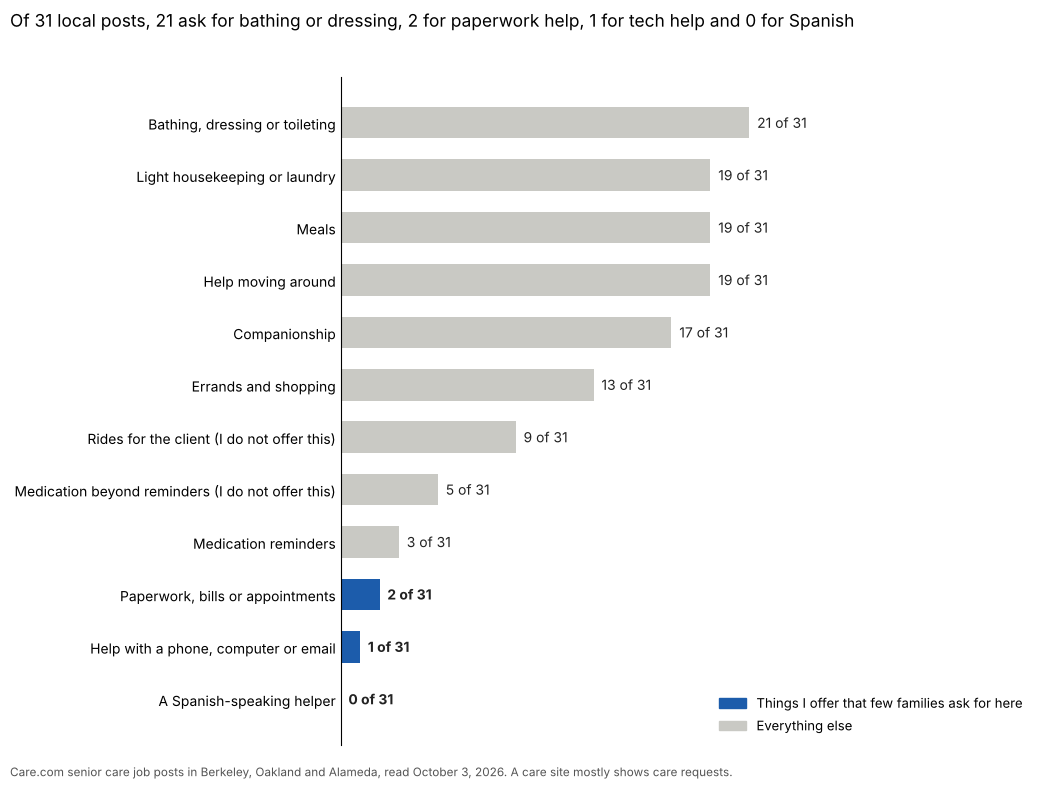

In [9]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

ypos = list(range(len(counts)))[::-1]   # first row at the top
BLUE, GRAY = "#1c5cab", "#c9c9c4"

fig, ax = plt.subplots(figsize=(10.5, 0.5 * len(counts) + 1.9))
ax.barh(ypos, counts["local_posts"], color=[BLUE if e else GRAY for e in counts["my_edge"]], height=0.6)
for y, (_, r) in zip(ypos, counts.iterrows()):
    ax.text(r["local_posts"] + 0.4, y, f"{r['local_posts']} of {N_LOCAL}", va="center", fontsize=10, color="#222222",
            fontweight="bold" if r["my_edge"] else "normal")
ax.set_yticks(ypos)
ax.set_yticklabels(counts["what"], fontsize=10)
ax.set_xlim(0, N_LOCAL * 1.15)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=GRAY)]
ax.legend(handles, ["Things I offer that few families ask for here", "Everything else"],
          loc="lower right", frameon=False, fontsize=9.5)
care_n, paper, tech, spanish = (counts.loc[k, "local_posts"] for k in ["personal_care", "paperwork_admin", "tech_help", "spanish"])
fig.suptitle(f"Of {N_LOCAL} local posts, {care_n} ask for bathing or dressing, {paper} for paperwork help, {tech} for tech help and {spanish} for Spanish",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, "Care.com senior care job posts in Berkeley, Oakland and Alameda, read October 3, 2026. "
                     "A care site mostly shows care requests.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(f"{OUT}/what_families_ask_for.png", dpi=150)
counts.round(3).to_csv(f"{OUT}/what_families_ask_for.csv")
pd.DataFrame(fit_rows, columns=["rule", "local_posts_left"]).to_csv(f"{OUT}/family_posts_that_fit.csv", index=False)
plt.show()

## 9. What I decided

These are decisions I had already made, checked against what families post.

- **Does my care offer match what families ask for?** Yes. The most-asked tasks are bathing and dressing, meals, housekeeping, help moving around, companionship and errands, and I do all of them.
- **Keep the rule that I do not drive clients?** Yes. It rules out about 9 of the 31 local posts, and I accept that.
- **Keep medication reminders only?** Yes. 5 of the 31 local posts want medication managed or given, which is outside what I do.
- **Keep &#36;35 an hour and the 4-hour minimum?** Yes, as decided in notebook 05. This notebook shows the cost of that on Care.com: only 4 of the 31 local posts pass every one of my rules and reach &#36;35.

### Still open

- **Is Care.com worth my time as a place to find clients?** Most families there budget &#36;30 or less and many want full-time help.
- **Should I take visits shorter than 4 hours?** About half of the posts with a clear visit length want less than 4 hours.
- **Which of the families' words do I use in my own wording?** "Patient" and "reliable" come up most.

### Limits to remember
- Nearly all of this is one site on one day. Care.com is where families go after deciding they need a caregiver, so it shows care requests and hides other needs.
- The senior care form offers tick boxes for care tasks and none for paperwork or technology. Those only show up when a family types them.
- 31 local posts is a small number. Treat the small counts (Spanish, paperwork, technology, visit length) as "rare here", not as rates.
- A post is a wish list. It is not a hire, and the pay range is an opening offer.
- I read the posts through a page-reading tool and recorded them by hand. I re-checked the key quotes, but a judgment call on one post can move a count by one.
- The eight eldercare.com posts have no dates and are left out of the counts.